![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)


# Introducción a los Embeddings y Rags
## Definiciones preliminares

* Profesor : [Carlos Daniel Jiménez Martínez](danieljimenez88m@gmail.com)

* Objetivo de la clase : Introducir al estudiante en conceptos de AI Generativa, tokens, embeddings  y arquitecturas transformers



### Conceptos Claves

* Token : La unidad base de un modelo de lenguaje

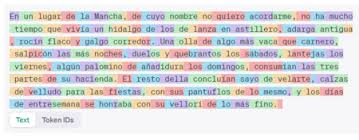

* La necesidad de medir todo en Tokens (en el mundo de los LLMS ) consiste en la reducción del vocabulario que usa un modelo, para asi poder atender una tarea particular con el mismo de manera más eficiente.


### Modelos de lenguaje:

* Masked Lenguage Model : Es un modelo que esta entrenado para predecir un token que se encuentra enmascarado o perdido en una secuencia de texto 

    > El mejor disco de ___ es Division Bell

    > El mejor disco de **Pink Floyd** es Division Bell

    * Los modelos Enmascarados no son GenAI

* Autoregresive Language Model: Es un modelo que esta entrenado para predecir el siguiente token en una secuencia :

    > La vida es un ___

    > La vida es un **Carnaval**

    * Es un GenAI

* Generative AI : En modelos de lenguaje son todos aquellos que tienen un final abierto 

* Rag: (Definición # 1) Tipo de base de dato que trabaja u obedece a instrucciones del modelo de lenguaje



### Stack de AI Engineering

* [OpenAI](https://openai.com/es-419/
* [Gemini](https://gemini.google.com/app?hl=es)
* [Antropic](https://www.anthropic.com/)
* [Ollama](https://ollama.com/)
* [Hugging Face](https://huggingface.co/models)
* [Docker](https://www.docker.com/)
* [FastAPI](https://fastapi.tiangolo.com/advanced/)


### Capas del AI Stack 

* Desarrollo de aplicaciones: Esta capa se centra en utilizar modelos fundacionales ya existentes para construir aplicaciones. Involucra la creación de interfaces de IA, la ingeniería de prompts, la construcción de contexto (como sistemas RAG o agentes) y una evaluación rigurosa

* Desarrollo de modelos : Proporciona las herramientas para crear y adaptar los modelos en sí. Incluye frameworks de modelado, entrenamiento, finetuning (ajuste fino), optimización de inferencia y la ingeniería de datasets (conjuntos de datos), además de su respectiva evaluación

    * El mayor cuello de botella predicho se ha hecho realidad: nos hemos quedado sin datos de internet públicos generados por humanos para entrenar nuevos modelos, por lo tanto, en la capa de desarrollo de modelos de 2026, la síntesis de datos impulsada por IA es la norma absoluta para mejorar la cantidad, cobertura y calidad del entrenamiento.
    * Asimismo, técnicas de finetuning como LoRA o QLoRA (que reducen drásticamente la memoria necesaria) son estándares de la industria que permiten a las empresas adaptar modelos abiertos de forma muy económica

* Infraestructura: IaC en la nube o Edge Computing (por ejemplo la Raspberry PI)

In [1]:
#######################
# ---- Librerias ---- #
#######################

from transformers import AutoTokenizer
import tiktoken
import warnings
warnings.filterwarnings('ignore')

/Users/carlosdaniel/Desktop/HENRY_EMBEDDINGS_RAGS/Clase1/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


### Análisis de una canción Nuevecita
![Don Omar](https://www.qhubobogota.com/wp-content/uploads/2023/02/WhatsApp-Image-2023-02-08-at-3.54.44-PM.jpeg)
[▶ Ver en YouTube](https://www.youtube.com/watch?v=lRWqYR3e7xE)

In [ ]:
import tiktoken

### Funciones auxiliares
colors = [
    '102;194;165', '252;141;98', '141;160;203',
    '231;138;195', '166;216;84', '255;217;47'
]

def show_tokens_openai(sentence: str, 
                       model_name: str = "gpt-4o"):
    try:
        tokenizer = tiktoken.encoding_for_model(model_name)
    except KeyError:
        print(f"Modelo {model_name} no encontrado, usando tokenizador por defecto.")
        tokenizer = tiktoken.get_encoding("cl100k_base")

    
    token_ids = tokenizer.encode(sentence)

    print(f"Modelo: {model_name}")
    print(f"Tokenizador: {tokenizer.name}")
    print(f"Vocab length: {tokenizer.n_vocab}")
    print("-" * 40)

    # Imprimir una lista coloreada de tokens
    for idx, t in enumerate(token_ids):
        # En tiktoken, decodificamos el array con el token individual
        token_str = tokenizer.decode([t])
        
        # Aplicamos el color de fondo usando códigos ANSI.
        print(
            f'\x1b[0;30;48;2;{colors[idx % len(colors)]}m{token_str}\x1b[0m',
            end=''
        )
    print() 

### Tu texto (Sentence)
letra_danza_kuduro = """A&X
El Orfanato
¡Danza Kuduro!
(Plop, plop, plop, plop, plop, plop, plop)
¡Lucenzo! (El Orfanato)
¡El rey!
La mano arriba, cintura sola
Da media vuelta, danza kuduro
No te canse' ahora, que esto solo empieza
Mueve la cabeza, danza kuduro
La mano arriba, cintura sola
Da media vuelta, danza kuduro
No te canse' ahora, que esto solo empieza
Mueve la cabeza, danza kuduro
Quién puede domar la fuerza del mal
Que se mete por tu' vena' (¡Don!)
Lo caliente del Sol que se te metió
Y no te deja quieta, nena (¡toma, toma!)
Quién puede parar eso que al bailar
Descontrola tu' cadera' (sexy)
Y ese fuego que quema por dentro y lento
Te convierte en fiera"""

show_tokens_openai(letra_danza_kuduro, "gpt-4o")

Modelo: gpt-4o
Tokenizador: o200k_base
Vocab length: 200019
----------------------------------------
A&X
El Orfanato
¡Danza Kuduro!
(Plop, plop, plop, plop, plop, plop, plop)
¡Lucenzo! (El Orfanato)
¡El rey!
La mano arriba, cintura sola
Da media vuelta, danza kuduro
No te canse' ahora, que esto solo empieza
Mueve la cabeza, danza kuduro
La mano arriba, cintura sola
Da media vuelta, danza kuduro
No te canse' ahora, que esto solo empieza
Mueve la cabeza, danza kuduro
Quién puede domar la fuerza del mal
Que se mete por tu' vena' (¡Don!)
Lo caliente del Sol que se te metió
Y no te deja quieta, nena (¡toma, toma!)
Quién puede parar eso que al bailar
Descontrola tu' cadera' (sexy)
Y ese fuego que quema por dentro y lento
Te convierte en fiera


## Utilidad de los tokens
### Midiendo probailidades de la siguiente palabra : Caso de Estudio Don Omar

* Base teoríca : Los modelos no escriben, sino que calculan una distribución de probabilidad para ver que palabra es la más probable a ir en un espaico ,dentro de un glosario.

    * Con esto se puede medir la incertidumbre
    * Control de Alucinaciones 
    * Clasificacion estrucurada de las palabras o tokens 

In [ ]:
import math
import os
from openai import OpenAI
from dotenv import load_dotenv
import config  
client = OpenAI() 


In [ ]:

def visualizar_probabilidades_siguiente_token(
    texto_incompleto: str,
    model: str = "gpt-5.2",
    top_k: int = 5,
    max_completion_tokens: int = 32,
):
    if not texto_incompleto or not texto_incompleto.strip():
        raise ValueError("El texto no puede estar vacío.")

    if not 0 <= top_k <= 20:
        raise ValueError("top_k debe estar entre 0 y 20.")

    messages = [
        {
            "role": "system",
            "content": (
                "Eres un motor de autocompletado. "
                "Continúa exactamente el texto del usuario. "
                "No expliques, no saludes, no agregues comillas."
            ),
        },
        {
            "role": "user",
            "content": texto_incompleto,
        },
    ]

    print(f"Texto a completar: {texto_incompleto!r}")
    print("-" * 70)

    try:
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            max_completion_tokens=max_completion_tokens,
            logprobs=True,
            top_logprobs=top_k,
            temperature=0,
            reasoning_effort="none",
        )

    except BadRequestError as e:
        print("Error en la llamada a la API:")
        print(e)
        return

    choice = response.choices[0]

    if choice.logprobs is None or not choice.logprobs.content:
        print("El modelo no devolvió logprobs.")
        return

    token_data = choice.logprobs.content[0]

    print(f"Primer token generado: {token_data.token!r}")
    print()
    print("Top tokens candidatos para la primera posición generada:")
    print("-" * 70)

    for opcion in token_data.top_logprobs or []:
        probabilidad = math.exp(opcion.logprob) * 100
        barra_longitud = min(int(probabilidad / 2), 50)
        barra_visual = "█" * barra_longitud

        print(
            f"{opcion.token!r:<20} | "
            f"{probabilidad:>7.3f}% | "
            f"logprob={opcion.logprob:>8.4f} | "
            f"{barra_visual}"
        )

In [31]:
contexto_cancion = "La mano arriba, cintura sola"
visualizar_probabilidades_siguiente_token(
    texto_incompleto=contexto_cancion,
    model="gpt-5.2",
    top_k=5
)

Texto a completar: 'La mano arriba, cintura sola'
----------------------------------------------------------------------
Primer token generado: 'da'

Top tokens candidatos para la primera posición generada:
----------------------------------------------------------------------
'da'                 |  61.009% | logprob= -0.4942 | ██████████████████████████████
'Da'                 |  37.004% | logprob= -0.9942 | ██████████████████
